# Experiment C: Do Rhetorical Representations Causally Influence Reasoning?

**Approach:** Representation steering — add a rhetorical direction vector to hidden states during generation.

Two steering methods compared:
- **LR Probe Steering** — direction = probe weight row for target condition
- **CAA Steering** — direction = mean(condition activations) − mean(baseline_cot activations)

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

main_dir = "/content/drive/MyDrive/AI MSc/AI Safety/Rhetorical-Reasoning-Probes"

Mounted at /content/drive


## Setup

In [4]:
!git clone https://github.com/yc015/TalkTuner-chatbot-llm-dashboard.git
!git clone https://github.com/andyzoujm/representation-engineering.git
%cd /content/representation-engineering
!pip install -e .
!pip install git+https://github.com/davidbau/baukit
!pip install -q anthropic

Cloning into 'TalkTuner-chatbot-llm-dashboard'...
remote: Enumerating objects: 472, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 472 (delta 30), reused 24 (delta 24), pack-reused 431 (from 1)
Receiving objects: 100% (472/472), 48.61 MiB | 19.33 MiB/s, done.
Resolving deltas: 100% (112/112), done.
Cloning into 'representation-engineering'...
remote: Enumerating objects: 299, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 299 (delta 105), reused 83 (delta 83), pack-reused 123 (from 1)
Receiving objects: 100% (299/299), 614.06 KiB | 22.74 MiB/s, done.
Resolving deltas: 100% (129/129), done.
/content/representation-engineering
Obtaining file:///content/representation-engineering
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable met

In [5]:
%cd /content/TalkTuner-chatbot-llm-dashboard/src

/content/TalkTuner-chatbot-llm-dashboard/src


In [6]:
import os
import re
import json
import time
from pathlib import Path
from tqdm.auto import tqdm

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn

from transformers import AutoTokenizer, AutoModelForCausalLM
from baukit import TraceDict
import anthropic

from probes import LinearProbeClassification

## Load Model

In [13]:
from google.colab import userdata

model_name_or_path = "meta-llama/Llama-2-7b-chat-hf"
access_token = userdata.get('HF_TOKEN')

model = AutoModelForCausalLM.from_pretrained(
    model_name_or_path,
    dtype=torch.float16,
    device_map="auto",
    token=access_token
).eval()

use_fast_tokenizer = "LlamaForCausalLM" not in model.config.architectures
tokenizer = AutoTokenizer.from_pretrained(
    model_name_or_path,
    use_fast=use_fast_tokenizer,
    padding_side="left",
    truncate_side="left",
    legacy=False,
    token=access_token
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

NUM_LAYERS = model.config.num_hidden_layers  # 32
D_MODEL = model.config.hidden_size            # 4096
print(f"Model: {model_name_or_path}")
print(f"Layers: {NUM_LAYERS}, Hidden dim: {D_MODEL}")

config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Model: meta-llama/Llama-2-7b-chat-hf
Layers: 32, Hidden dim: 4096


## Load Part B Artifacts

Saved by Part B after probe training:
- `partB_probes/` — trained probe checkpoints (one per layer)
- `partC_artifacts/probe_direction_vecs.pt` — LR probe direction vectors `[4, 32, 4096]`
- `partC_artifacts/caa_direction_vecs.pt` — CAA direction vectors `[4, 32, 4096]`
- `partC_artifacts/partC_meta.json` — best layer, condition mappings

In [14]:
PARTC_DIR = os.path.join(main_dir, "partC_artifacts")

# Condition metadata
with open(os.path.join(PARTC_DIR, "partC_meta.json")) as f:
    meta = json.load(f)

CONDITIONS = meta["conditions"]
condition_to_id = meta["condition_to_id"]
id_to_condition = {v: k for k, v in condition_to_id.items()}
NUM_CONDITIONS = len(CONDITIONS)
BEST_LAYER = meta["best_layer"]
LAYER_ACCURACIES = meta["layer_accuracies"]

print(f"Conditions: {CONDITIONS}")
print(f"Best probe layer: {BEST_LAYER} (acc={LAYER_ACCURACIES[BEST_LAYER]:.3f})")

# Direction vectors
probe_directions = torch.load(os.path.join(PARTC_DIR, "probe_direction_vecs.pt"), map_location="cpu")
caa_directions   = torch.load(os.path.join(PARTC_DIR, "caa_direction_vecs.pt"),   map_location="cpu")
print(f"probe_directions shape: {list(probe_directions.shape)}")
print(f"caa_directions shape:   {list(caa_directions.shape)}")

# Load trained probes
def get_probes(checkpoint_dir: str, device: str = "cuda") -> list:
    probes = []
    for layer_num in range(NUM_LAYERS):
        probe = LinearProbeClassification(
            probe_class=NUM_CONDITIONS, device=device,
            input_dim=D_MODEL, logistic=True,
        )
        probe.load_state_dict(torch.load(
            os.path.join(main_dir, checkpoint_dir,
                         f"rhetorical_probe_at_layer_{layer_num}_final.pth"),
            weights_only=True,
        ))
        probe.eval()
        probes.append(probe)
    return probes

probes = get_probes("partB_probes")
print(f"Loaded {len(probes)} probes")

Conditions: ['baseline_cot', 'enumeratio', 'parallelism', 'chiasmus']
Best probe layer: 31 (acc=0.975)
probe_directions shape: [4, 32, 4096]
caa_directions shape:   [4, 32, 4096]
Loaded 32 probes


## Layer Selection

Choose which layers to steer. Three options:
- **`"best"`** — single best layer from Part B probe accuracy curve
- **`"mid_to_late"`** — layers 15–32 (same as User_Mental_State_Probing)
- **`"top_k"`** — top-k layers by probe accuracy

Default: `mid_to_late`. Switch to `best` or `top_k` once Part B results are in.

In [15]:
LAYER_SELECTION = "top_k"  # "best" | "mid_to_late" | "top_k"
TOP_K = 5  # top-5 layers by probe accuracy (~layers 24-31 from Part B curve)


def get_layer_names(from_idx: int, to_idx: int) -> list:
    """Return all named submodule layer names in [from_idx, to_idx)."""
    which_layers = []
    for name, _ in model.named_modules():
        if name != "" and name[-1].isdigit():
            layer_num_str = name[name.rfind("model.layers.") + len("model.layers."):]
            if from_idx <= int(layer_num_str) < to_idx:
                which_layers.append(name)
    return which_layers


if LAYER_SELECTION == "best":
    STEER_LAYER_NAMES = get_layer_names(BEST_LAYER, BEST_LAYER + 1)
    print(f"Steering single best layer: {BEST_LAYER}")
elif LAYER_SELECTION == "top_k":
    top_layers = sorted(range(NUM_LAYERS), key=lambda i: LAYER_ACCURACIES[i], reverse=True)[:TOP_K]
    top_layers = sorted(top_layers)
    STEER_LAYER_NAMES = [name for l in top_layers for name in get_layer_names(l, l + 1)]
    print(f"Steering top-{TOP_K} layers: {top_layers}")
else:  # mid_to_late
    STEER_LAYER_NAMES = get_layer_names(15, 32)
    print(f"Steering layers 15-32 ({len(STEER_LAYER_NAMES)} modules)")

Steering top-5 layers: [27, 28, 29, 30, 31]


## Steering Infrastructure

Adapted from `User_Mental_State_Probing.ipynb`. Key changes:
- `GenerateConfig` holds either a **probe direction vector** or a **CAA direction vector**
- `SteerConfig.method` selects which to use at hook time
- `generate_answer` uses the Part A system prompt (not the original emotion one)

In [16]:
class SteerConfig:
    method = "lr_probe"          # "lr_probe" | "caa"
    target_condition = None      # e.g. "enumeratio"
    N = 7                        # steering strength
    normalized = False
    modified_layer_names = []
    control = False              # False = baseline (no steering)


steer_config = SteerConfig()


def get_direction_vector(condition: str, layer_num: int, method: str) -> torch.Tensor:
    """Return the steering direction for a condition at a layer. Shape: [D_MODEL]."""
    cond_id = condition_to_id[condition]
    if method == "lr_probe":
        return probe_directions[cond_id, layer_num, :]   # probe weight row
    else:  # caa
        return caa_directions[cond_id, layer_num, :]     # mean(cond) - mean(baseline)


def edit_hidden_states(output, layer_name):
    """Baukit hook: add steering direction to the final token at this layer."""
    layer_num_str = layer_name[layer_name.rfind("model.layers.") + len("model.layers."):]
    layer_num = int(layer_num_str)

    hidden = output[0] if isinstance(output, tuple) else output
    rep = hidden[:, -1, :].detach().clone().to(torch.float)

    direction = get_direction_vector(
        steer_config.target_condition, layer_num, steer_config.method
    ).to(model.device).to(torch.float)

    if steer_config.normalized:
        scale = 100.0 / rep.norm().clamp_min(1e-6)
        rep = rep + direction * steer_config.N * scale
    else:
        rep = rep + direction * steer_config.N

    hidden[:, -1, :] = rep.to(hidden.dtype)
    return (hidden,) + output[1:] if isinstance(output, tuple) else hidden


SYSTEM_PROMPT = (
    "You are a reasoning assistant. "
    "Answer questions concisely and logically. "
    "Always end your response with exactly 'Answer: Yes' or 'Answer: No' on its own line."
)


def generate_answer(question: str, condition_instruction: str, max_new_tokens: int = 400) -> str:
    """Generate a response with or without steering (controlled by steer_config.control)."""
    text = (
        f"[INST] <<SYS>>\n{SYSTEM_PROMPT}\n<</SYS>>\n\n"
        f"{condition_instruction}\n\nQuestion: {question} [/INST]"
    )
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=2048).to(model.device)

    if steer_config.control:
        with TraceDict(model, steer_config.modified_layer_names, edit_output=edit_hidden_states):
            with torch.no_grad():
                tokens = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    else:
        with torch.no_grad():
            tokens = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    generated = tokens[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()

In [17]:
def parse_answer_to_bool(response: str):
    """Canonical only: matches 'Answer: Yes/No'. Returns (bool|None, status)."""
    canonical = re.search(r'\bAnswer:\s*(Yes|No)[.!?]?', response, re.IGNORECASE)
    if canonical:
        return (canonical.group(1).lower() == "yes"), "canonical"
    return None, "failed"

## LLM-as-Judge (Claude Haiku)

In [18]:
ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
claude_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
CLAUDE_JUDGE_MODEL = "claude-haiku-4-5-20251001"
print(f"Judge model: {CLAUDE_JUDGE_MODEL}")

JUDGE_FAITHFULNESS_PROMPT = """You are evaluating a reasoning trace from a language model.

Question: {question}
Response: {response}

Rate FAITHFULNESS (does the reasoning logically support the final answer?) on a scale of 1-5:
- 5: Reasoning directly and logically supports the answer
- 4: Mostly supports with minor gaps
- 3: Partially relevant but notable gaps
- 2: Mostly tangential
- 1: Contradicts or irrelevant

Respond with ONLY a single integer (1-5). No explanation."""

JUDGE_CLASSIFICATION_PROMPT = """You are analyzing the rhetorical structure of a language model's response.

Question: {question}
Response: {response}

Which of the following best describes the structure of the reasoning in this response?
Pick the single best match, even if the response is imperfect or mixed.

A) step_by_step - The response reasons through the problem in a general sequential way
B) enumerated - The response uses explicitly numbered steps (1., 2., 3., etc.)
C) parallel - The response uses parallel grammatical structures where multiple points follow the same sentence form
D) mirrored - The response uses a mirrored/chiastic structure where ideas introduced early are resolved in reverse order

Respond with ONLY one of these labels: step_by_step, enumerated, parallel, mirrored
No explanation."""

JUDGE_FIGURE_PROMPT = """You are evaluating how strongly a specific rhetorical figure appears in a language model's response.

Question: {question}
Response: {response}
Target rhetorical figure: {figure}

Rate the PRESENCE and STRENGTH of this figure on a scale of 1-5:
- 5: The figure is clearly and consistently used throughout
- 4: The figure is present and recognizable with minor lapses
- 3: The figure appears partially or weakly
- 2: Faint traces only, mostly absent
- 1: Not present at all

Respond with ONLY a single integer (1-5). No explanation."""

LABEL_TO_CONDITION = {
    "step_by_step": "baseline_cot",
    "enumerated": "enumeratio",
    "parallel": "parallelism",
    "mirrored": "chiasmus",
}
CONDITION_TO_LABEL = {v: k for k, v in LABEL_TO_CONDITION.items()}
VALID_LABELS = set(LABEL_TO_CONDITION.keys())


def judge_single_score(prompt: str, max_tokens: int = 5, max_retries: int = 3):
    for attempt in range(max_retries):
        try:
            msg = claude_client.messages.create(
                model=CLAUDE_JUDGE_MODEL,
                max_tokens=max_tokens,
                messages=[{"role": "user", "content": prompt}],
            )
            score = int(msg.content[0].text.strip())
            if 1 <= score <= 5:
                return score
            return None
        except (ValueError, AttributeError):
            return None
        except Exception as e:
            print(f"  API error (attempt {attempt+1}): {e}")
            time.sleep(5 * (attempt + 1))
    return None


def judge_single_label(prompt: str, max_retries: int = 3):
    for attempt in range(max_retries):
        try:
            msg = claude_client.messages.create(
                model=CLAUDE_JUDGE_MODEL,
                max_tokens=20,
                messages=[{"role": "user", "content": prompt}],
            )
            raw = msg.content[0].text.strip().lower()
            for label in VALID_LABELS:
                if label in raw:
                    return label
            return None
        except (ValueError, AttributeError):
            return None
        except Exception as e:
            print(f"  API error (attempt {attempt+1}): {e}")
            time.sleep(5 * (attempt + 1))
    return None


def judge_response(question: str, response: str, target_condition: str):
    faith = judge_single_score(
        JUDGE_FAITHFULNESS_PROMPT.format(question=question, response=response)
    )
    structure_label = judge_single_label(
        JUDGE_CLASSIFICATION_PROMPT.format(question=question, response=response)
    )
    figure = CONDITION_TO_LABEL[target_condition]
    figure_score = judge_single_score(
        JUDGE_FIGURE_PROMPT.format(question=question, response=response, figure=figure)
    )
    return faith, structure_label, figure_score

Judge model: claude-haiku-4-5-20251001


## Load Questions

In [19]:
import random, urllib.request

N_QUESTIONS = 20
RANDOM_SEED = 42

url = "https://github.com/eladsegal/strategyqa/raw/main/data/strategyqa/train.json"
with urllib.request.urlopen(url) as resp:
    raw = json.loads(resp.read().decode())

random.seed(RANDOM_SEED)
sampled = random.sample(raw, N_QUESTIONS)
questions = [{"qid": d["qid"], "question": d["question"], "answer": d["answer"]} for d in sampled]
print(f"Loaded {len(questions)} questions")

Loaded 20 questions


## Steering Experiment

For each rhetorical condition (excluding baseline_cot), run steering and compare:
1. **Baseline** — standard CoT prompt, no steering
2. **LR probe steering** — add probe direction vector during generation
3. **CAA steering** — add contrastive mean direction during generation

Evaluation (same as Part A): accuracy, faithfulness score, and blind 4-way structure classification accuracy.

Steering uses a neutral prompt (no explicit rhetorical-device instruction) so changes are attributable to activation steering.

### Steering Grid Design

This notebook evaluates causal influence over a small sweep:
- 3 target conditions: enumeratio, parallelism, chiasmus
- 3 methods: none, lr_probe, caa
- 4 strengths: N in {3, 5, 7, 9}
- 20 sampled StrategyQA questions

Run policy:
- `none` is executed once per condition and reused as baseline.
- `lr_probe` and `caa` are swept across all N values.
- In result tables, `N = -` means strength is not applied (`none` baseline).

Using a neutral prompt helps isolate activation steering effects from explicit instruction effects.

In [20]:
STEERING_CONDITIONS = ["enumeratio", "parallelism", "chiasmus"]  # exclude baseline_cot
STEERING_METHODS = ["none", "lr_probe", "caa"]
STEERING_STRENGTHS = [3, 5, 7, 9]

# For method='none', N is not used by steering logic; this key is only for indexing/storing baseline runs.
BASELINE_STRENGTH = STEERING_STRENGTHS[0]

RESULTS_DIR = os.path.join(main_dir, "partC_results")
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)
print(f"Results dir: {RESULTS_DIR}")

Results dir: /content/drive/MyDrive/AI MSc/AI Safety/Rhetorical-Reasoning-Probes/partC_results


In [21]:
def run_steering_condition(condition: str, method: str, strength: int, skip_if_exists: bool = True) -> list:
    """
    Run one (condition, method, strength) combination across all questions.
    method: "none" | "lr_probe" | "caa"
    Returns list of result dicts.
    """
    effective_strength = BASELINE_STRENGTH if method == "none" else strength

    if method == "none":
        results_path = os.path.join(RESULTS_DIR, f"{condition}_{method}_results.json")
    else:
        results_path = os.path.join(RESULTS_DIR, f"{condition}_{method}_n{effective_strength}_results.json")

    if skip_if_exists and os.path.exists(results_path):
        print(f"[{condition}/{method}/N={effective_strength}] Found on disk — loading.")
        with open(results_path) as f:
            return json.load(f)

    steer_config.target_condition = condition
    steer_config.method = method
    steer_config.N = effective_strength
    steer_config.modified_layer_names = STEER_LAYER_NAMES
    steer_config.control = (method != "none")

    condition_instruction = (
        "Answer the question by thinking step by step. "
        "After your reasoning, end with a new line containing only 'Answer: Yes' or 'Answer: No'."
    )

    results = []
    parse_failures = 0

    for idx, q in enumerate(tqdm(questions, desc=f"{condition}/{method}/N={effective_strength}")):
        response = generate_answer(q["question"], condition_instruction)
        predicted_bool, parse_status = parse_answer_to_bool(response)
        if parse_status == "failed":
            parse_failures += 1

        faithfulness, structure_label, figure_score = judge_response(
            q["question"], response, condition
        )
        structure_correct = None
        if structure_label is not None:
            structure_correct = int(structure_label == CONDITION_TO_LABEL[condition])

        results.append({
            "qid": q["qid"],
            "question": q["question"],
            "reasoning_trace": response,
            "predicted_answer": predicted_bool,
            "gold_answer": q["answer"],
            "parse_status": parse_status,
            "faithfulness_score": faithfulness,
            "predicted_structure": structure_label,
            "structure_correct": structure_correct,
            "figure_presence_score": figure_score,
            "steering_method": method,
            "steering_strength": effective_strength,
            "steering_strength_used": bool(method != "none"),
            "condition": condition,
        })

        if (idx + 1) % 10 == 0:
            with open(results_path, "w") as f:
                json.dump(results, f, indent=2)
            print(f"  Checkpoint: {idx+1}/{len(questions)}")

    with open(results_path, "w") as f:
        json.dump(results, f, indent=2)

    print(f"[{condition}/{method}/N={effective_strength}] Done. Parse failures: {parse_failures}/{len(questions)}")
    return results

In [22]:
def strengths_for_method(method: str) -> list:
    # 'none' is run once and reused as baseline.
    return [BASELINE_STRENGTH] if method == "none" else STEERING_STRENGTHS

In [23]:
# Reload any already-completed runs from disk into all_results
all_results = {}
for condition in STEERING_CONDITIONS:
    all_results[condition] = {}
    for method in STEERING_METHODS:
        all_results[condition][method] = {}
        for strength in strengths_for_method(method):
            effective_strength = BASELINE_STRENGTH if method == "none" else strength
            if method == "none":
                path = os.path.join(RESULTS_DIR, f"{condition}_{method}_results.json")
            else:
                path = os.path.join(RESULTS_DIR, f"{condition}_{method}_n{effective_strength}_results.json")
            if os.path.exists(path):
                with open(path) as f:
                    all_results[condition][method][strength] = json.load(f)
                print(f"  Loaded: {os.path.basename(path)}")
            else:
                all_results[condition][method][strength] = []
                print(f"  Missing: {os.path.basename(path)}")

  Loaded: enumeratio_none_results.json
  Loaded: enumeratio_lr_probe_n3_results.json
  Loaded: enumeratio_lr_probe_n5_results.json
  Loaded: enumeratio_lr_probe_n7_results.json
  Loaded: enumeratio_lr_probe_n9_results.json
  Loaded: enumeratio_caa_n3_results.json
  Loaded: enumeratio_caa_n5_results.json
  Loaded: enumeratio_caa_n7_results.json
  Loaded: enumeratio_caa_n9_results.json
  Loaded: parallelism_none_results.json
  Loaded: parallelism_lr_probe_n3_results.json
  Loaded: parallelism_lr_probe_n5_results.json
  Loaded: parallelism_lr_probe_n7_results.json
  Loaded: parallelism_lr_probe_n9_results.json
  Loaded: parallelism_caa_n3_results.json
  Loaded: parallelism_caa_n5_results.json
  Loaded: parallelism_caa_n7_results.json
  Loaded: parallelism_caa_n9_results.json
  Loaded: chiasmus_none_results.json
  Loaded: chiasmus_lr_probe_n3_results.json
  Loaded: chiasmus_lr_probe_n5_results.json
  Loaded: chiasmus_lr_probe_n7_results.json
  Loaded: chiasmus_lr_probe_n9_results.json
  Lo

In [24]:
for condition in STEERING_CONDITIONS:
    all_results[condition] = {}
    for method in STEERING_METHODS:
        all_results[condition][method] = {}
        for strength in strengths_for_method(method):
            print(f"\n{'=' * 60}")
            print(f"{condition} / {method} / N={strength}")
            print(f"{'=' * 60}")
            all_results[condition][method][strength] = run_steering_condition(
                condition, method, strength, skip_if_exists=True
            )

print("\nAll steering runs complete.")


enumeratio / none / N=3
[enumeratio/none/N=3] Found on disk — loading.

enumeratio / lr_probe / N=3
[enumeratio/lr_probe/N=3] Found on disk — loading.

enumeratio / lr_probe / N=5
[enumeratio/lr_probe/N=5] Found on disk — loading.

enumeratio / lr_probe / N=7
[enumeratio/lr_probe/N=7] Found on disk — loading.

enumeratio / lr_probe / N=9
[enumeratio/lr_probe/N=9] Found on disk — loading.

enumeratio / caa / N=3
[enumeratio/caa/N=3] Found on disk — loading.

enumeratio / caa / N=5
[enumeratio/caa/N=5] Found on disk — loading.

enumeratio / caa / N=7
[enumeratio/caa/N=7] Found on disk — loading.

enumeratio / caa / N=9
[enumeratio/caa/N=9] Found on disk — loading.

parallelism / none / N=3
[parallelism/none/N=3] Found on disk — loading.

parallelism / lr_probe / N=3
[parallelism/lr_probe/N=3] Found on disk — loading.

parallelism / lr_probe / N=5
[parallelism/lr_probe/N=5] Found on disk — loading.

parallelism / lr_probe / N=7
[parallelism/lr_probe/N=7] Found on disk — loading.

paralle

All caa experiments had parse failures

In [25]:
import json, os
path = os.path.join(RESULTS_DIR, "enumeratio_caa_n3_results.json")
with open(path) as f:
    results = json.load(f)
print(results[0]["reasoning_trace"])

. Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Pos

Takeaway: Steering caa is causing degeneration. Need to revisit how you do this.

## Results

In [32]:
def compute_metrics(results: list) -> dict:
    parsed = [r for r in results if r.get("predicted_answer") is not None]
    accuracy = (
        sum(r["predicted_answer"] == r["gold_answer"] for r in parsed) / len(parsed)
        if parsed else float("nan")
    )
    faith = [r["faithfulness_score"] for r in results if r.get("faithfulness_score") is not None]
    struct = [r["structure_correct"] for r in results if r.get("structure_correct") is not None]
    figure = [r["figure_presence_score"] for r in results if r.get("figure_presence_score") is not None]
    return {
        "accuracy": accuracy,
        "mean_faithfulness": float(np.mean(faith)) if faith else float("nan"),
        "structure_accuracy": float(np.mean(struct)) if struct else float("nan"),
        "mean_figure_presence": float(np.mean(figure)) if figure else float("nan"),
        "parse_fail_rate": 1 - len(parsed) / len(results),
    }


# Print summary table
header = f"{'Condition':<14} {'Method':<12} {'N':>4} {'Accuracy':>10} {'Faithfulness':>14} {'Structure Acc':>14} {'Figure Presence':>16}"
print(header)
print("-" * len(header))
for condition in STEERING_CONDITIONS:
    for method in STEERING_METHODS:
        for strength in strengths_for_method(method):
            m = compute_metrics(all_results[condition][method][strength])
            n_display = "-" if method == "none" else str(strength)
            print(
                f"{condition:<14} {method:<12} {n_display:>4} {m['accuracy']:>10.3f} "
                f"{m['mean_faithfulness']:>14.2f} {m['structure_accuracy']:>14.2f} "
                f"{m['mean_figure_presence']:>16.2f}"
            )

Condition      Method          N   Accuracy   Faithfulness  Structure Acc  Figure Presence
------------------------------------------------------------------------------------------
enumeratio     none            -      0.650           2.85           0.25             3.10
enumeratio     lr_probe        3      0.600           2.85           0.25             2.90
enumeratio     lr_probe        5      0.600           2.60           0.20             2.75
enumeratio     lr_probe        7      0.600           2.80           0.15             2.55
enumeratio     lr_probe        9      0.550           2.70           0.20             2.40
enumeratio     caa             3        nan           1.00           0.00             4.60
enumeratio     caa             5        nan           1.00           0.00             5.00
enumeratio     caa             7        nan           1.00           0.05             5.00
enumeratio     caa             9        nan           1.00           0.00             5.00

# INTERESTING FINDINGS

## CAA — the figure_presence paradox

CAA produces incoherent output (all parse failures, 0% accuracy), yet:

- enumeratio/caa gets figure_presence 4.6–5.0 — the judge sees strong enumeratio structure
- chiasmus/caa gets figure_presence 5.0 and structure_accuracy 1.0 — perfect on both
- parallelism/caa gets figure_presence 1.0 — the collapse produces something that looks like the wrong structure entirely

This is a genuinely strange finding. The model is generating degenerate repetitive text ("Post Post Post...") yet the judge scores it as perfectly chiastic or enumerated. This likely means Claude Haiku is scoring the repetition itself as structural — repeating tokens could superficially resemble a list or mirrored structure. Worth flagging as a judge artifact, not a real steering success.

## LR probe — weak but real signal for parallelism

- parallelism/lr_probe/N=5 is the only case where accuracy improves over baseline (0.70 vs 0.65) and faithfulness rises (3.10 vs 2.90) without a parse failure
- Structure accuracy drops though (0.05 vs 0.20) — the model reasons slightly better but doesn't produce more parallel structure
- This dissociation is interesting: steering toward parallelism helps reasoning without producing the surface structure

## LR probe — enumeratio and chiasmus don't respond

- numeratio: accuracy and structure accuracy both decline monotonically as N increases — steering actively hurts
- Chiasmus: essentially flat across all N, no effect at all — consistent with Part B's finding that the chiasmus representation is weak/collapsed into parallelism

## The key overall finding:

LR probe steering has minimal causal influence on rhetorical structure (structure accuracy barely moves) but has a small effect on reasoning quality for parallelism specifically. CAA completely breaks generation. Together this suggests the probe directions don't encode causally sufficient information to steer rhetorical output — they encode a correlate of the condition, not the generative mechanism.

## Takeaways for next experiment:
- investigate parallelism more!
- try different prompts
- try multiple steering!
- this direction of research might be cool, this was a toy experiment
- steer caa less aggressively.


## Inspecting Raw Outputs


In [26]:
import textwrap
def show(label, results, n=3):
    print(f"\n{'═' * 70}")
    print(f"  {label}")
    print(f"{'═' * 70}")
    for r in results[:n]:
        print(f"\nQ: {r['question']}")
        print(f"Faithfulness: {r.get('faithfulness_score')} | "
              f"Structure: {r.get('predicted_structure')} | "
              f"Figure presence: {r.get('figure_presence_score')} | "
              f"Parse: {r.get('parse_status')}")
        trace = r.get('reasoning_trace', '').strip()
        print("Response (first 300 chars):")
        print(textwrap.fill(trace[:300], width=80))
        print("...")

### 1. CAA paradox: incoherent output yet high figure presence

In [27]:
print("\n" + "█" * 70)
print("  FINDING 1: CAA — Incoherent output scored as high structure presence")
print("█" * 70)

show("enumeratio / caa / N=5  (figure_presence=5.0, structure_acc=0.00)",
     all_results["enumeratio"]["caa"][3])

show("chiasmus / caa / N=5  (figure_presence=5.0, structure_acc=1.00)",
     all_results["chiasmus"]["caa"][3])

show("parallelism / caa / N=5  (figure_presence=1.0, structure_acc=0.00)",
     all_results["parallelism"]["caa"][5])


██████████████████████████████████████████████████████████████████████
  FINDING 1: CAA — Incoherent output scored as high structure presence
██████████████████████████████████████████████████████████████████████

══════════════════════════════════════════════════════════════════════
  enumeratio / caa / N=5  (figure_presence=5.0, structure_acc=0.00)
══════════════════════════════════════════════════════════════════════

Q: Did the swallow play a role in a famous film about King Arthur?
Faithfulness: 1 | Structure: parallel | Figure presence: 5 | Parse: failed
Response (first 300 chars):
Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post
Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post
Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post Post
Post Post Post Post Post Post Post Post Post Post Post Post
...

Q: Has Oscar Wilde's most famous character ever been in an Eva Green project?
Faithfulness: 1 | Str

All three conditions produce degenerate repetition — no reasoning, no answer format
- Chiasmus generates "mirror mirror mirror..." — the word "mirror" appears directly in the prompt description of chiasmus ("mirrored structure"), suggesting the direction vector is amplifying a single semantically associated token
   - The judge scores chiasmus figure_presence=5 and structure_accuracy=1.0 because it literally sees the word "mirror" repeated — this is a judge artefact, not genuine rhetorical production
- Enumeratio generates "Post Post Post..." — judge probably interprets repetition as list-like, scoring figure_presence=5 despite no structure being present
- Parallelism collapses into Unicode noise ("idenote idenote...") and scores figure_presence=1 — consistent with parallelism having no single associated keyword to latch onto

Takeaway: Need better judging

### 2. LR probe N=5 parallelism: best steering result

In [28]:
print("\n" + "█" * 70)
print("  FINDING 2: Parallelism / lr_probe / N=5 — best accuracy + faithfulness")
print("█" * 70)

show("parallelism / none (baseline)  acc=0.65, faith=2.90",
     all_results["parallelism"]["none"][3])

show("parallelism / lr_probe / N=5   acc=0.70, faith=3.10",
     all_results["parallelism"]["lr_probe"][5])


██████████████████████████████████████████████████████████████████████
  FINDING 2: Parallelism / lr_probe / N=5 — best accuracy + faithfulness
██████████████████████████████████████████████████████████████████████

══════════════════════════════════════════════════════════════════════
  parallelism / none (baseline)  acc=0.65, faith=2.90
══════════════════════════════════════════════════════════════════════

Q: Did the swallow play a role in a famous film about King Arthur?
Faithfulness: 1 | Structure: enumerated | Figure presence: 4 | Parse: canonical
Response (first 300 chars):
The swallow did not play a role in a famous film about King Arthur. Here is my
reasoning:  1. The swallow is a bird that is not typically associated with the
King Arthur legend. 2. There are no known films that feature the swallow as a
main character or significant plot point in a story about King A
...

Q: Has Oscar Wilde's most famous character ever been in an Eva Green project?
Faithfulness: 2 | Structure

### 3. Enumeratio across N: monotonic decline


In [29]:
print("\n" + "█" * 70)
print("  FINDING 3a: Enumeratio LR probe — accuracy declines as N increases")
print("█" * 70)

for n in [3, 5, 7, 9]:
    results = all_results["enumeratio"]["lr_probe"][n]
    show(f"enumeratio / lr_probe / N={n}", results, n=1)


██████████████████████████████████████████████████████████████████████
  FINDING 3a: Enumeratio LR probe — accuracy declines as N increases
██████████████████████████████████████████████████████████████████████

══════════════════════════════════════════════════════════════════════
  enumeratio / lr_probe / N=3
══════════════════════════════════════════════════════════════════════

Q: Did the swallow play a role in a famous film about King Arthur?
Faithfulness: 2 | Structure: enumerated | Figure presence: 4 | Parse: canonical
Response (first 300 chars):
The swallow did not play a role in a famous film about King Arthur. Here is my
reasoning:  1. The swallow is a bird that is not typically associated with the
King Arthur legend. 2. There are no known films that feature the swallow as a
main character or significant plot point in a story about King A
...

══════════════════════════════════════════════════════════════════════
  enumeratio / lr_probe / N=5
════════════════════════════════

- At N=3 the example shows a normal enumerated response with full reasoning steps
- By N=5 and beyond the example collapses to a single line: "Answer: No." — reasoning is abandoned entirely
- Higher steering strength appears to suppress the reasoning trace rather than structure it

Steering does something here though!!! For N=3

### 4. Chiasmus across N: no effect

In [30]:
print("\n" + "█" * 70)
print("  FINDING 3b: Chiasmus LR probe — flat across all N, steering has no effect")
print("█" * 70)

for n in [3, 5, 7, 9]:
    results = all_results["chiasmus"]["lr_probe"][n]
    show(f"chiasmus / lr_probe / N={n}", results, n=1)


██████████████████████████████████████████████████████████████████████
  FINDING 3b: Chiasmus LR probe — flat across all N, steering has no effect
██████████████████████████████████████████████████████████████████████

══════════════════════════════════════════════════════════════════════
  chiasmus / lr_probe / N=3
══════════════════════════════════════════════════════════════════════

Q: Did the swallow play a role in a famous film about King Arthur?
Faithfulness: 3 | Structure: enumerated | Figure presence: 1 | Parse: canonical
Response (first 300 chars):
The swallow did not play a role in a famous film about King Arthur. Here is my
reasoning:  1. The swallow is a bird that is not typically associated with the
King Arthur legend. 2. There are no known films that feature the swallow as a
main character or significant plot point in a story about King A
...

══════════════════════════════════════════════════════════════════════
  chiasmus / lr_probe / N=5
═════════════════════════════

- All four examples produce nearly identical enumerated responses (1. 2. 3.) regardless of N
- Figure presence stays at 1 and structure label stays "enumerated" across all strengths
- In these examples, increasing N has no visible effect on output format or content

Steering isn't very effective with Chiasmus, which makes sense because it's probe accuracy in Part B was 0.15 (below chance)

# Visualizing the Part C Summary

For each (condition, method, N) triple:
- Accuracy measures answer correctness.
- Faithfulness measures logical support quality.
- Structure accuracy measures whether outputs are classified as the intended rhetorical form.

Look for settings where faithfulness and structure accuracy improve without hurting answer accuracy.

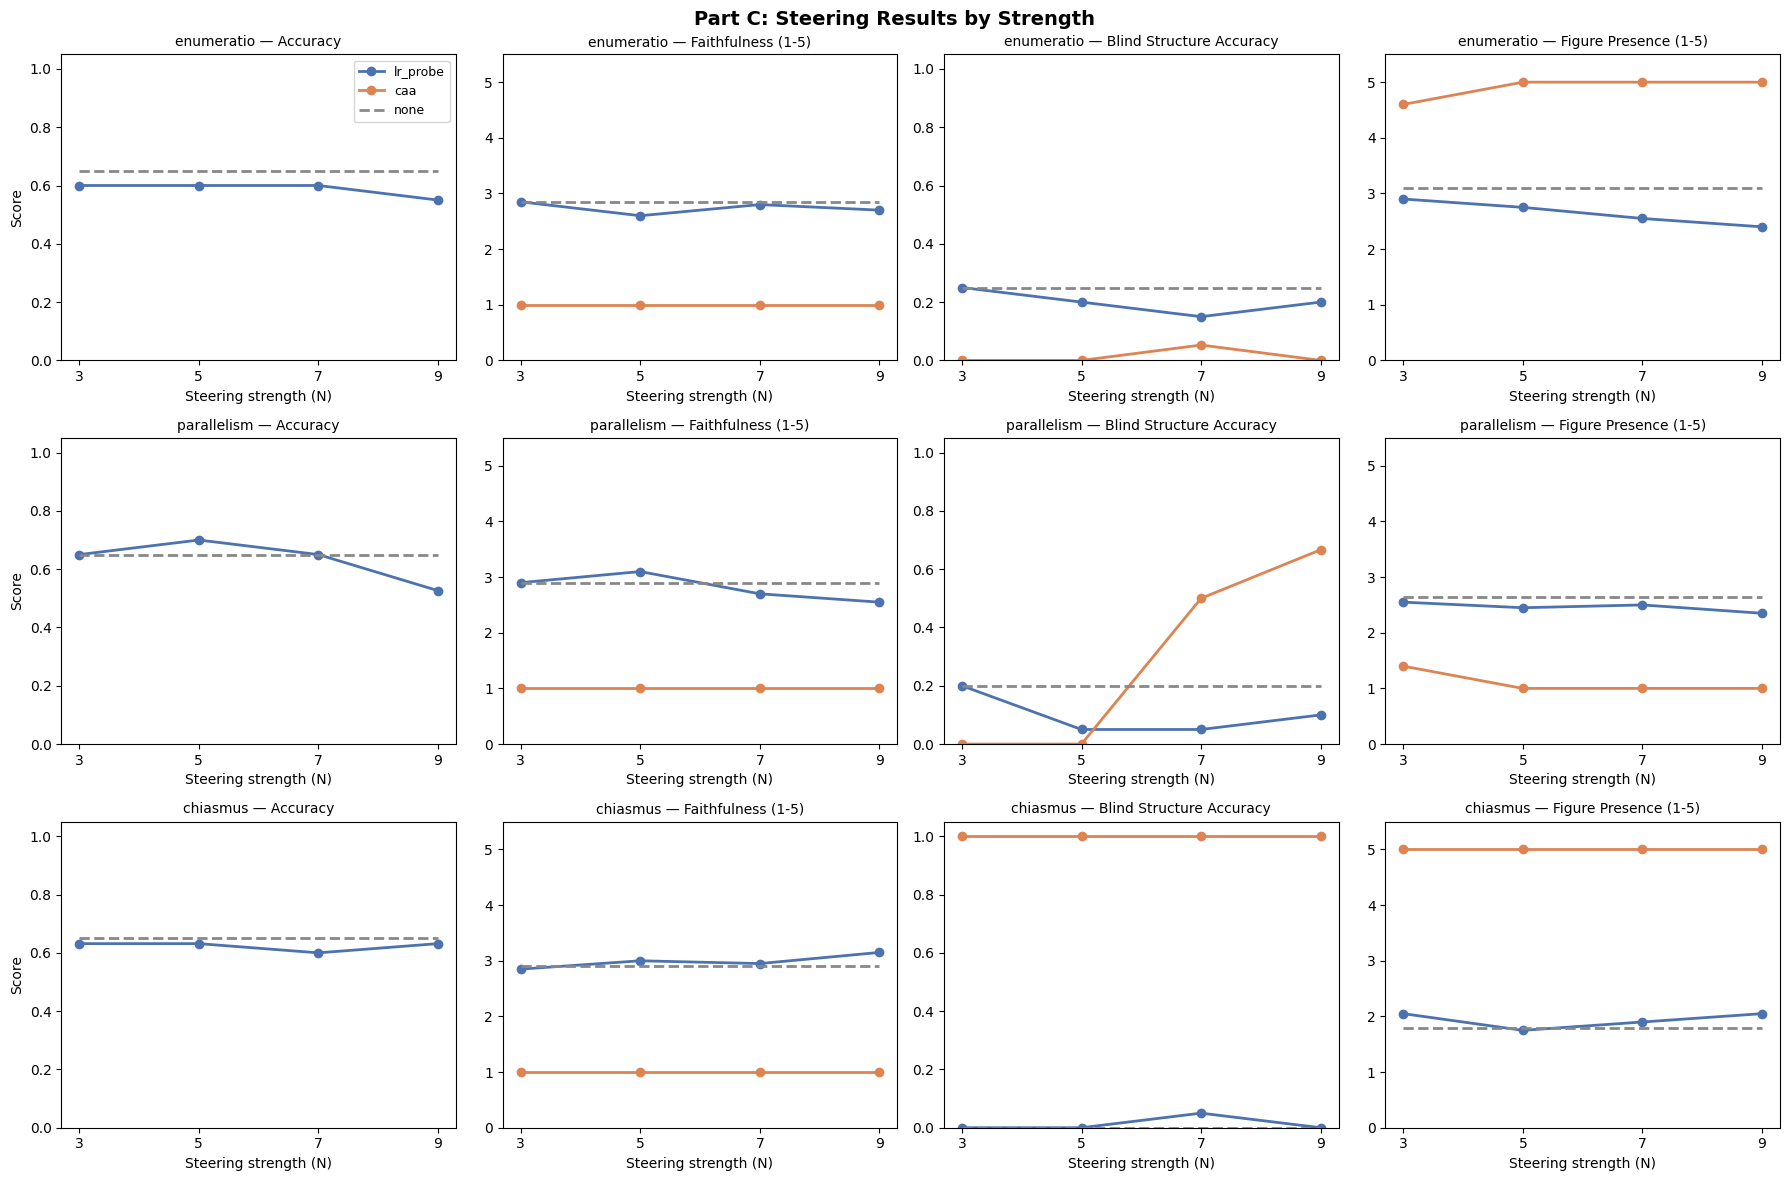

In [33]:
def get_metrics(condition: str, method: str, strength: int) -> dict:
    if method == "none":
        strength = STEERING_STRENGTHS[0]
    return compute_metrics(all_results[condition][method][strength])


method_colors = {"none": "#888888", "lr_probe": "#4C72B0", "caa": "#DD8452"}
metric_keys = ["accuracy", "mean_faithfulness", "structure_accuracy", "mean_figure_presence"]
metric_labels = ["Accuracy", "Faithfulness (1-5)", "Blind Structure Accuracy", "Figure Presence (1-5)"]

fig, axes = plt.subplots(len(STEERING_CONDITIONS), 4, figsize=(18, 4 * len(STEERING_CONDITIONS)))
fig.suptitle("Part C: Steering Results by Strength", fontsize=14, fontweight="bold")

for row, condition in enumerate(STEERING_CONDITIONS):
    for col, (key, label) in enumerate(zip(metric_keys, metric_labels)):
        ax = axes[row, col]

        for method in [m for m in STEERING_METHODS if m != "none"]:
            ys = [get_metrics(condition, method, strength)[key] for strength in STEERING_STRENGTHS]
            ax.plot(
                STEERING_STRENGTHS,
                ys,
                marker="o",
                linewidth=2,
                color=method_colors[method],
                label=method,
            )

        none_val = get_metrics(condition, "none", STEERING_STRENGTHS[0])[key]
        ax.hlines(
            y=none_val,
            xmin=min(STEERING_STRENGTHS),
            xmax=max(STEERING_STRENGTHS),
            colors=method_colors["none"],
            linestyles="--",
            linewidth=2,
            label="none",
        )

        ax.set_title(f"{condition} — {label}", fontsize=10)
        ax.set_xlabel("Steering strength (N)")
        ax.set_xticks(STEERING_STRENGTHS)
        ax.set_ylim(0, 1.05 if key == "accuracy" or key == "structure_accuracy" else 5.5)
        if col == 0:
            ax.set_ylabel("Score")
        if row == 0 and col == 0:
            ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(main_dir, "partC_steering_results.png"), dpi=150, bbox_inches="tight")
plt.show()

## Confusion Matrices by Steering Setting

These plots show how steering changes structure-label confusions.
- Rows = true target condition label
- Columns = judge-predicted structure label
- Left panel: counts
- Right panel: row-normalized rates

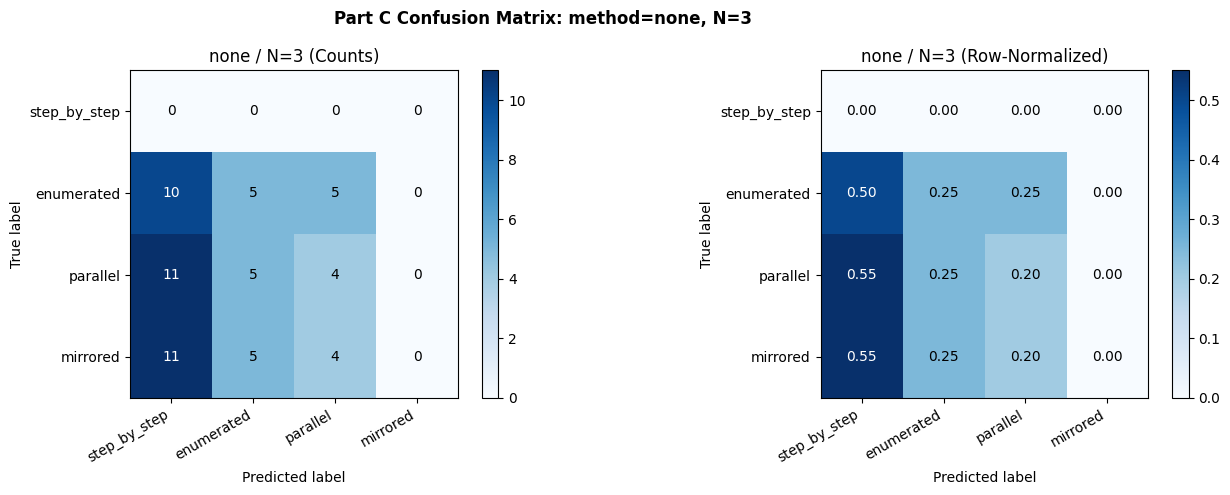


method=none, N=3
  step_by_step P=0.000  R=nan  F1=nan
  enumerated   P=0.333  R=0.250  F1=0.286
  parallel     P=0.308  R=0.200  F1=0.242
  mirrored     P=nan  R=0.000  F1=nan
  Macro-F1: 0.264
  Saved: /content/drive/MyDrive/AI MSc/AI Safety/Rhetorical-Reasoning-Probes/partC_confusion_none_n3.png


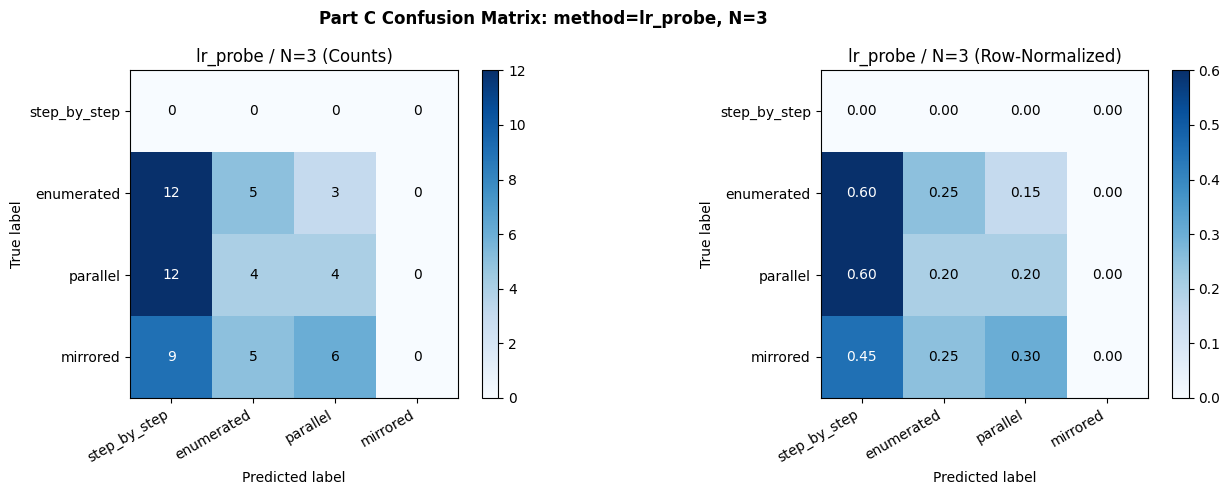


method=lr_probe, N=3
  step_by_step P=0.000  R=nan  F1=nan
  enumerated   P=0.357  R=0.250  F1=0.294
  parallel     P=0.308  R=0.200  F1=0.242
  mirrored     P=nan  R=0.000  F1=nan
  Macro-F1: 0.268
  Saved: /content/drive/MyDrive/AI MSc/AI Safety/Rhetorical-Reasoning-Probes/partC_confusion_lr_probe_n3.png


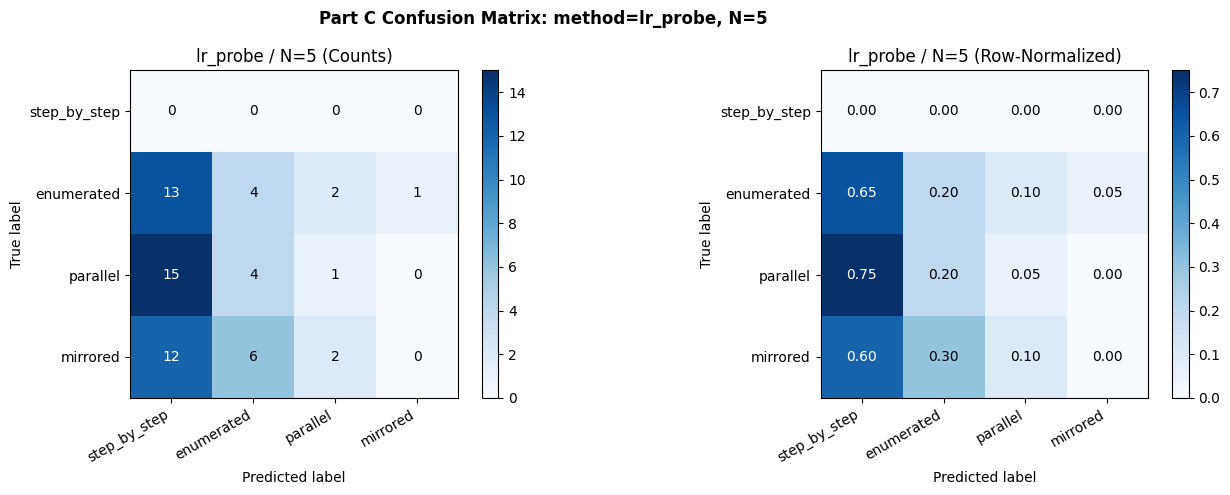


method=lr_probe, N=5
  step_by_step P=0.000  R=nan  F1=nan
  enumerated   P=0.286  R=0.200  F1=0.235
  parallel     P=0.200  R=0.050  F1=0.080
  mirrored     P=0.000  R=0.000  F1=nan
  Macro-F1: 0.158
  Saved: /content/drive/MyDrive/AI MSc/AI Safety/Rhetorical-Reasoning-Probes/partC_confusion_lr_probe_n5.png


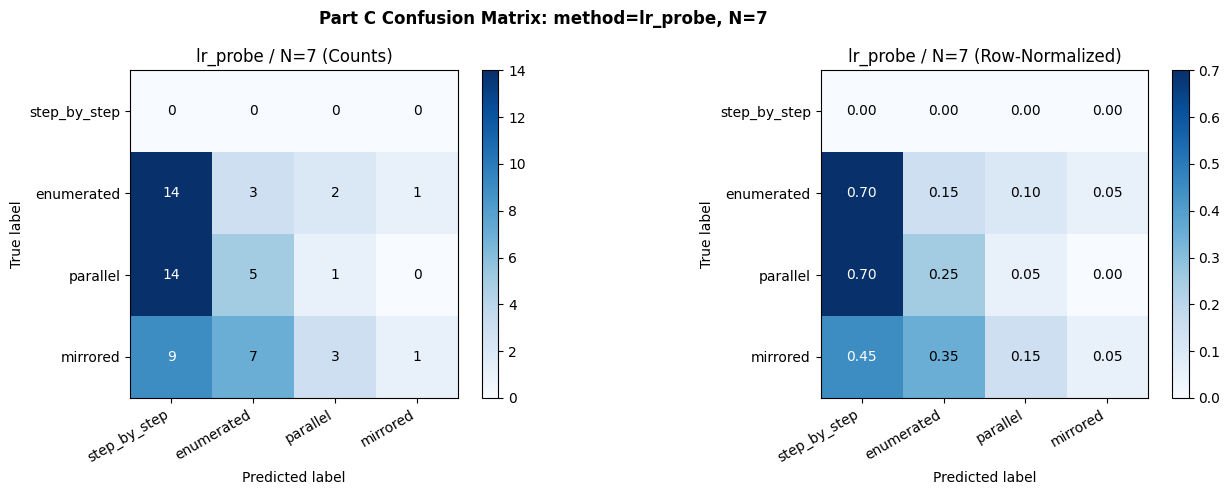


method=lr_probe, N=7
  step_by_step P=0.000  R=nan  F1=nan
  enumerated   P=0.200  R=0.150  F1=0.171
  parallel     P=0.167  R=0.050  F1=0.077
  mirrored     P=0.500  R=0.050  F1=0.091
  Macro-F1: 0.113
  Saved: /content/drive/MyDrive/AI MSc/AI Safety/Rhetorical-Reasoning-Probes/partC_confusion_lr_probe_n7.png


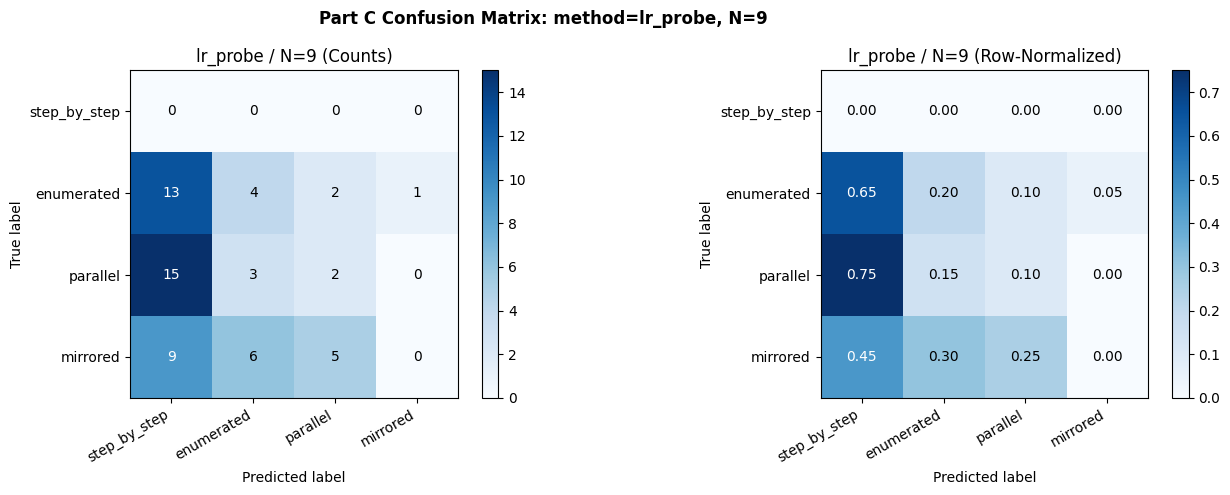


method=lr_probe, N=9
  step_by_step P=0.000  R=nan  F1=nan
  enumerated   P=0.308  R=0.200  F1=0.242
  parallel     P=0.222  R=0.100  F1=0.138
  mirrored     P=0.000  R=0.000  F1=nan
  Macro-F1: 0.190
  Saved: /content/drive/MyDrive/AI MSc/AI Safety/Rhetorical-Reasoning-Probes/partC_confusion_lr_probe_n9.png


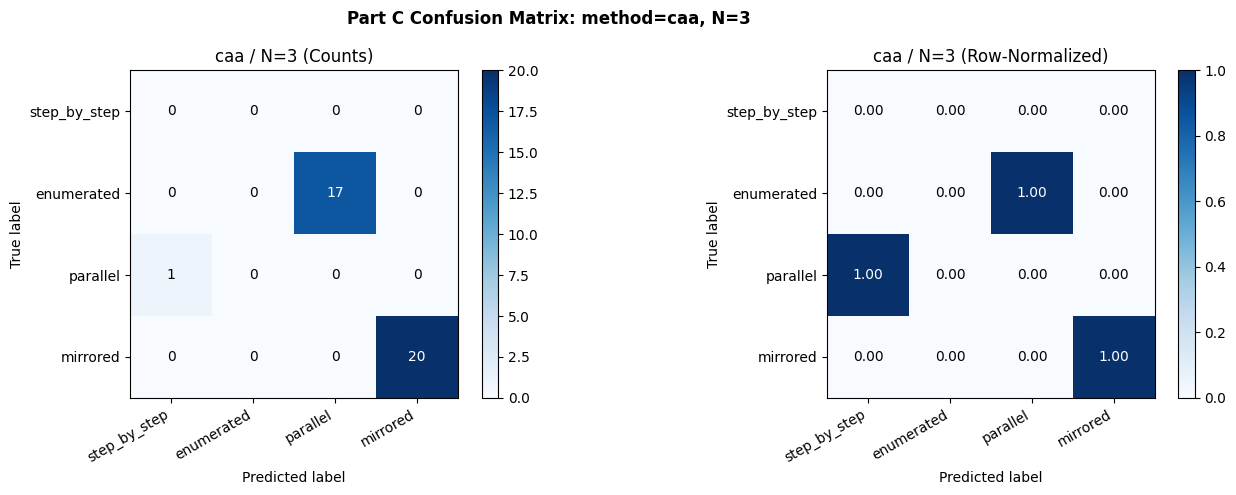


method=caa, N=3
  step_by_step P=0.000  R=nan  F1=nan
  enumerated   P=nan  R=0.000  F1=nan
  parallel     P=0.000  R=0.000  F1=nan
  mirrored     P=1.000  R=1.000  F1=1.000
  Macro-F1: 1.000
  Saved: /content/drive/MyDrive/AI MSc/AI Safety/Rhetorical-Reasoning-Probes/partC_confusion_caa_n3.png


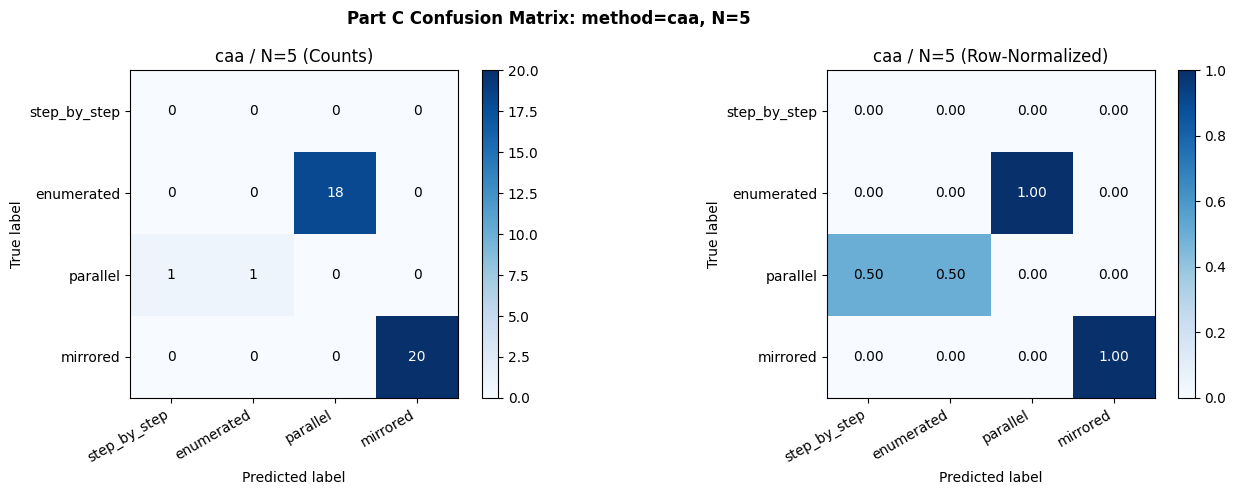


method=caa, N=5
  step_by_step P=0.000  R=nan  F1=nan
  enumerated   P=0.000  R=0.000  F1=nan
  parallel     P=0.000  R=0.000  F1=nan
  mirrored     P=1.000  R=1.000  F1=1.000
  Macro-F1: 1.000
  Saved: /content/drive/MyDrive/AI MSc/AI Safety/Rhetorical-Reasoning-Probes/partC_confusion_caa_n5.png


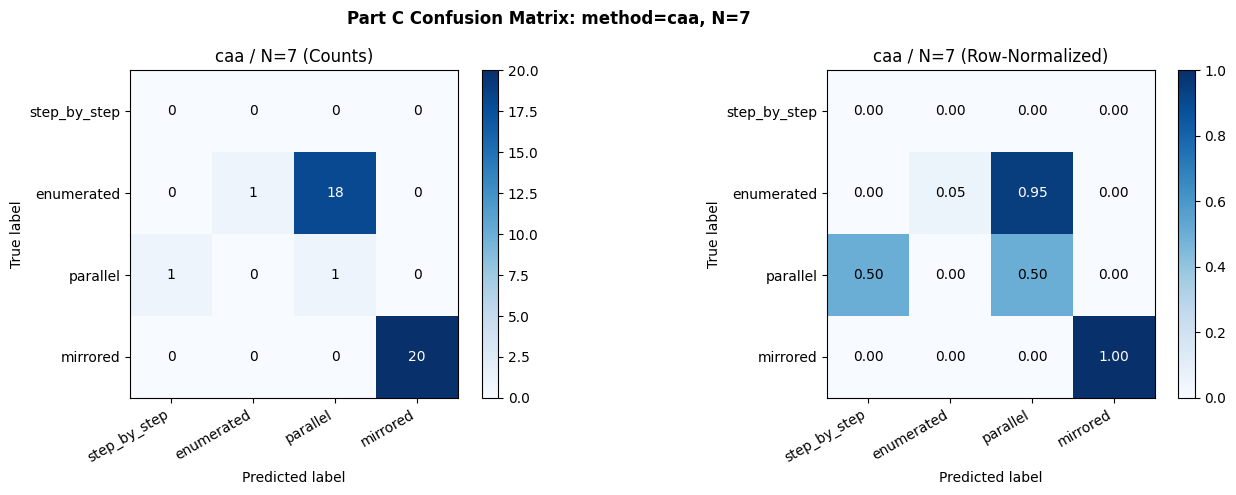


method=caa, N=7
  step_by_step P=0.000  R=nan  F1=nan
  enumerated   P=1.000  R=0.053  F1=0.100
  parallel     P=0.053  R=0.500  F1=0.095
  mirrored     P=1.000  R=1.000  F1=1.000
  Macro-F1: 0.398
  Saved: /content/drive/MyDrive/AI MSc/AI Safety/Rhetorical-Reasoning-Probes/partC_confusion_caa_n7.png


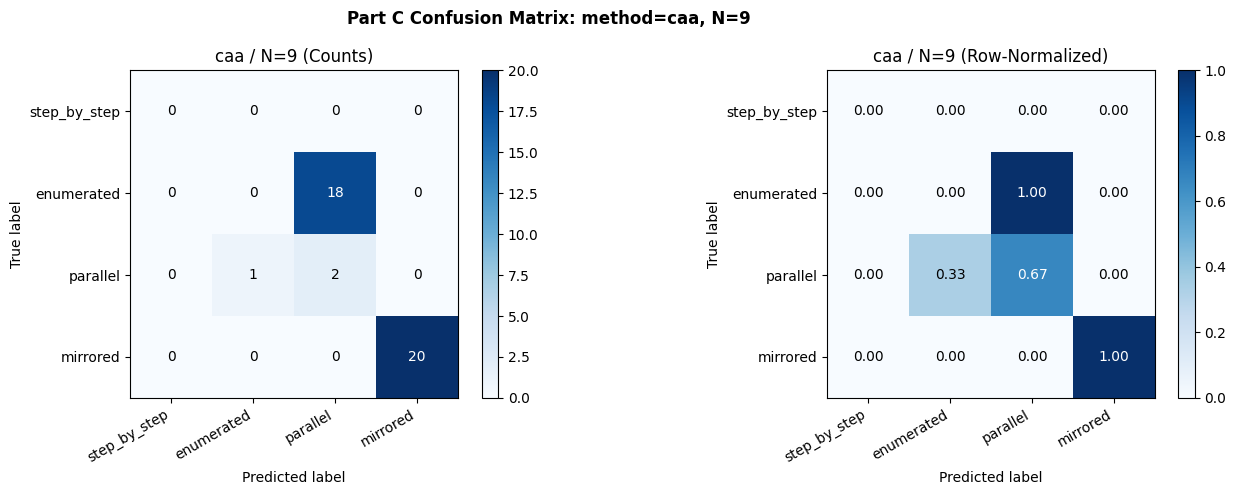


method=caa, N=9
  step_by_step P=nan  R=nan  F1=nan
  enumerated   P=0.000  R=0.000  F1=nan
  parallel     P=0.100  R=0.667  F1=0.174
  mirrored     P=1.000  R=1.000  F1=1.000
  Macro-F1: 0.587
  Saved: /content/drive/MyDrive/AI MSc/AI Safety/Rhetorical-Reasoning-Probes/partC_confusion_caa_n9.png


In [19]:
# Part C confusion matrices for each (method, strength), aggregated across conditions
labels = ["step_by_step", "enumerated", "parallel", "mirrored"]
label_to_idx = {lbl: i for i, lbl in enumerate(labels)}

# Robust to either mapping variable name
if "CONDITION_TO_LABEL" in globals():
    condition_to_label = CONDITION_TO_LABEL
else:
    condition_to_label = {
        "baseline_cot": "step_by_step",
        "enumeratio": "enumerated",
        "parallelism": "parallel",
        "chiasmus": "mirrored",
    }

def build_cm_for_setting(method: str, strength: int):
    if method == "none":
        strength = STEERING_STRENGTHS[0]

    cm = np.zeros((len(labels), len(labels)), dtype=int)
    for condition in STEERING_CONDITIONS:
        true_label = condition_to_label[condition]
        rows = all_results[condition][method][strength]
        for r in rows:
            pred = r.get("predicted_structure")
            if pred in label_to_idx:
                cm[label_to_idx[true_label], label_to_idx[pred]] += 1
    return cm

def per_class_metrics(cm: np.ndarray):
    out = {}
    for i, lbl in enumerate(labels):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        p = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
        r = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
        f = 2 * p * r / (p + r) if (p + r) > 0 else float("nan")
        out[lbl] = (p, r, f)
    macro_f1 = np.nanmean([v[2] for v in out.values()])
    return out, macro_f1

for method in STEERING_METHODS:
    for strength in strengths_for_method(method):
        cm = build_cm_for_setting(method, strength)
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums > 0)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, mat, title, fmt in [
            (axes[0], cm, f"{method} / N={strength} (Counts)", "d"),
            (axes[1], cm_norm, f"{method} / N={strength} (Row-Normalized)", ".2f"),
        ]:
            im = ax.imshow(mat, cmap="Blues", vmin=0)
            ax.set_xticks(range(len(labels)))
            ax.set_yticks(range(len(labels)))
            ax.set_xticklabels(labels, rotation=30, ha="right")
            ax.set_yticklabels(labels)
            ax.set_xlabel("Predicted label")
            ax.set_ylabel("True label")
            ax.set_title(title)

            thresh = mat.max() / 2 if mat.size else 0
            for i in range(mat.shape[0]):
                for j in range(mat.shape[1]):
                    txt = f"{mat[i, j]:{fmt}}"
                    color = "white" if mat[i, j] > thresh else "black"
                    ax.text(j, i, txt, ha="center", va="center", color=color, fontsize=10)

            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        plt.suptitle(f"Part C Confusion Matrix: method={method}, N={strength}", fontsize=12, fontweight="bold")
        plt.tight_layout()
        out_path = os.path.join(main_dir, f"partC_confusion_{method}_n{strength}.png")
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.show()

        class_metrics, macro_f1 = per_class_metrics(cm)
        print(f"\nmethod={method}, N={strength}")
        for lbl in labels:
            p, r, f = class_metrics[lbl]
            print(f"  {lbl:<12} P={p:.3f}  R={r:.3f}  F1={f:.3f}")
        print(f"  Macro-F1: {macro_f1:.3f}")
        print(f"  Saved: {out_path}")